# Dataset and hierarchy analysis

This notebook characterizes the three datasets used in the thesis experiments: **CIFAR-100**, **CUB-200-2011**, and **FGVC-Aircraft**. It reads the same configuration files and dataset adapters used during training, ensuring that split sizes, label IDs, and hierarchy edges match the corrected unified experimental protocol.

The analysis addresses four questions relevant to the experiments chapter:

1. How much data is available at each split and hierarchy level?
2. How balanced are the sample distributions and the hierarchy itself?
3. How do image scale and aspect ratio differ across datasets?
4. Which hierarchy properties may affect optimization and evaluation?

> **Hierarchy provenance.** CIFAR-100 combines the official 20 coarse and 100 fine labels with the published B-CNN 8-class upper edge. CUB uses the 13-order/38-family/200-species mapping retained from H-CAST. Aircraft reconstructs the official 30-manufacturer/70-family/100-variant hierarchy by joining the parallel official annotations. These are experimental taxonomies: their different provenance should be stated explicitly in the thesis.


In [1]:
from collections import Counter
from pathlib import Path
import os
import pickle
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from omegaconf import OmegaConf
from PIL import Image

# Work from either the repository root or analysis/.
cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'configs').is_dir() and (p / 'datasets').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('Run this notebook from the repository or one of its subdirectories.')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from datasets.aircraft import AircraftDataset
from datasets.cifar100 import CIFAR100Dataset
from datasets.cub import CUBDataset

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 9, 'figure.constrained_layout.use': True,
})
COLORS = {'CIFAR-100': '#0072B2', 'CUB-200-2011': '#009E73', 'FGVC-Aircraft': '#D55E00'}
SPLIT_COLORS = {'train': '#0072B2', 'val': '#E69F00', 'test': '#009E73'}
print(f'Repository: {REPO_ROOT}')


Repository: /home/g.saggini1/lexicographic_deep_learning_detailed_study


/home/g.saggini1/lexicographic_deep_learning_detailed_study/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Dataset roots follow the same environment variables as training (`CIFAR100_ROOT`, `CUB200_ROOT`, and `AIRCRAFT_ROOT`). Figures and tables are external runtime artifacts and are therefore written below `/scratch/g.saggini1/outputs` by default. Set `DATASET_ANALYSIS_OUTPUT` to override that location. Image geometry is sampled deterministically to keep reruns fast; increase `MAX_IMAGES_PER_SPLIT` for an exhaustive scan.


In [2]:
OUTPUT_DIR = Path(os.environ.get(
    'DATASET_ANALYSIS_OUTPUT',
    '/scratch/g.saggini1/outputs/analysis/datasets',
)).expanduser()
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
MAX_IMAGES_PER_SPLIT = 2_000
RANDOM_SEED = 2026

DATASET_SPECS = {
    'CIFAR-100': {
        'config': REPO_ROOT / 'configs/hcast/hcast_cifar100.yaml',
        'adapter': CIFAR100Dataset,
        'provenance': 'official fine/coarse labels + published B-CNN upper edge',
    },
    'CUB-200-2011': {
        'config': REPO_ROOT / 'configs/hcast/hcast_cub200.yaml',
        'adapter': CUBDataset,
        'provenance': 'official images/split + order/family mapping retained from H-CAST',
    },
    'FGVC-Aircraft': {
        'config': REPO_ROOT / 'configs/hcast/hcast_aircraft.yaml',
        'adapter': AircraftDataset,
        'provenance': 'official parallel manufacturer/family/variant annotations',
    },
}
print(f'Exports: {OUTPUT_DIR}')


Exports: /scratch/g.saggini1/outputs/analysis/datasets


## Load the experiment datasets

The training split creates the canonical label space. Validation and test then reuse it, exactly as in `datasets.loaders.build_dataloaders`. This prevents split-local remapping and verifies that every child has one consistent parent. No augmentation is applied in this descriptive analysis.


In [3]:
def load_experiment_datasets():
    loaded = {}
    for dataset_name, spec in DATASET_SPECS.items():
        cfg = OmegaConf.load(spec['config'])
        OmegaConf.resolve(cfg)
        adapter = spec['adapter']
        train = adapter(cfg=cfg, split='train', transform=None, label_space=None)
        split_datasets = {'train': train}
        for split in ('val', 'test'):
            split_datasets[split] = adapter(
                cfg=cfg, split=split, transform=None, label_space=train.label_space
            )
        loaded[dataset_name] = {'cfg': cfg, 'splits': split_datasets}
        sizes = ', '.join(f'{s}={len(ds):,}' for s, ds in split_datasets.items())
        print(f'{dataset_name}: {sizes}; classes={train.num_classes_per_level}')
    return loaded

datasets_by_name = load_experiment_datasets()


CIFAR-100: train=45,000, val=5,000, test=10,000; classes=[8, 20, 100]
CUB-200-2011: train=5,194, val=800, test=5,794; classes=[13, 38, 200]
FGVC-Aircraft: train=3,334, val=3,333, test=3,333; classes=[30, 70, 100]


In [4]:
def samples_dataframe(loaded):
    rows = []
    for dataset_name, bundle in loaded.items():
        levels = list(bundle['cfg'].dataset.levels)
        for split, dataset in bundle['splits'].items():
            for index, sample in enumerate(dataset.samples):
                row = {'dataset': dataset_name, 'split': split, 'sample_index': index}
                row.update({level: int(label) for level, label in zip(levels, sample['labels'])})
                rows.append(row)
    return pd.DataFrame(rows)

samples = samples_dataframe(datasets_by_name)
samples.head()


,dataset,split,sample_index,coarse1,coarse2,fine,order,family,species,manufacturer,variant
0,CIFAR-100,train,0,4.0,11.0,19.0,NaN,NaN,NaN,NaN,NaN
1,CIFAR-100,train,1,4.0,15.0,29.0,NaN,NaN,NaN,NaN,NaN
2,CIFAR-100,train,2,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN
3,CIFAR-100,train,3,6.0,14.0,11.0,NaN,NaN,NaN,NaN,NaN
4,CIFAR-100,train,4,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN


## Dataset scale and label granularity

The table separates the number of images from the number of semantic classes. `Classes (observed)` is split-specific; `Classes (taxonomy)` is the canonical training/authoritative label space used by every split. Samples per class are reported at the leaf level, where visual discrimination is most fine-grained.


In [5]:
def gini(values):
    x = np.asarray(values, dtype=float)
    if x.size == 0 or np.allclose(x.sum(), 0):
        return np.nan
    x = np.sort(x)
    n = x.size
    return float((2 * np.sum((np.arange(1, n + 1)) * x) / (n * x.sum())) - (n + 1) / n)

summary_rows = []
for dataset_name, bundle in datasets_by_name.items():
    levels = list(bundle['cfg'].dataset.levels)
    taxonomy_counts = bundle['splits']['train'].num_classes_per_level
    for split in ('train', 'val', 'test'):
        frame = samples.query('dataset == @dataset_name and split == @split')
        leaf_counts = frame[levels[-1]].value_counts().reindex(range(taxonomy_counts[-1]), fill_value=0)
        row = {
            'Dataset': dataset_name, 'Split': split, 'Images': len(frame),
            'Leaf samples min': int(leaf_counts.min()),
            'Leaf samples median': float(leaf_counts.median()),
            'Leaf samples max': int(leaf_counts.max()),
            'Leaf-count Gini': gini(leaf_counts),
        }
        for level, total in zip(levels, taxonomy_counts):
            row[f'{level} classes (observed)'] = int(frame[level].nunique())
            row[f'{level} classes (taxonomy)'] = int(total)
        summary_rows.append(row)

dataset_summary = pd.DataFrame(summary_rows)
dataset_summary.to_csv(TABLE_DIR / 'dataset_split_summary.csv', index=False)
display(dataset_summary.style.format({'Images': '{:,}', 'Leaf samples median': '{:.1f}', 'Leaf-count Gini': '{:.3f}'}))


,Dataset,Split,Images,Leaf samples min,Leaf samples median,Leaf samples max,Leaf-count Gini,coarse1 classes (observed),coarse1 classes (taxonomy),coarse2 classes (observed),coarse2 classes (taxonomy),fine classes (observed),fine classes (taxonomy),order classes (observed),order classes (taxonomy),family classes (observed),family classes (taxonomy),species classes (observed),species classes (taxonomy),manufacturer classes (observed),manufacturer classes (taxonomy),variant classes (observed),variant classes (taxonomy)
0,CIFAR-100,train,"45,000",450,450.0,450,0.000,8.000000,8.000000,20.000000,20.000000,100.000000,100.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
1,CIFAR-100,val,"5,000",50,50.0,50,0.000,8.000000,8.000000,20.000000,20.000000,100.000000,100.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,CIFAR-100,test,"10,000",100,100.0,100,0.000,8.000000,8.000000,20.000000,20.000000,100.000000,100.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
3,CUB-200-2011,train,"5,194",25,26.0,26,0.001,nan,nan,nan,nan,nan,nan,13.000000,13.000000,38.000000,38.000000,200.000000,200.000000,nan,nan,nan,nan
4,CUB-200-2011,val,800,4,4.0,4,0.000,nan,nan,nan,nan,nan,nan,13.000000,13.000000,38.000000,38.000000,200.000000,200.000000,nan,nan,nan,nan
5,CUB-200-2011,test,"5,794",11,30.0,30,0.031,nan,nan,nan,nan,nan,nan,13.000000,13.000000,38.000000,38.000000,200.000000,200.000000,nan,nan,nan,nan
6,FGVC-Aircraft,train,"3,334",33,33.0,34,0.007,nan,nan,nan,nan,nan,nan,nan,nan,70.000000,70.000000,nan,nan,30.000000,30.000000,100.000000,100.000000
7,FGVC-Aircraft,val,"3,333",33,33.0,34,0.007,nan,nan,nan,nan,nan,nan,nan,nan,70.000000,70.000000,nan,nan,30.000000,30.000000,100.000000,100.000000
8,FGVC-Aircraft,test,"3,333",33,33.0,34,0.007,nan,nan,nan,nan,nan,nan,nan,nan,70.000000,70.000000,nan,nan,30.000000,30.000000,100.000000,100.000000


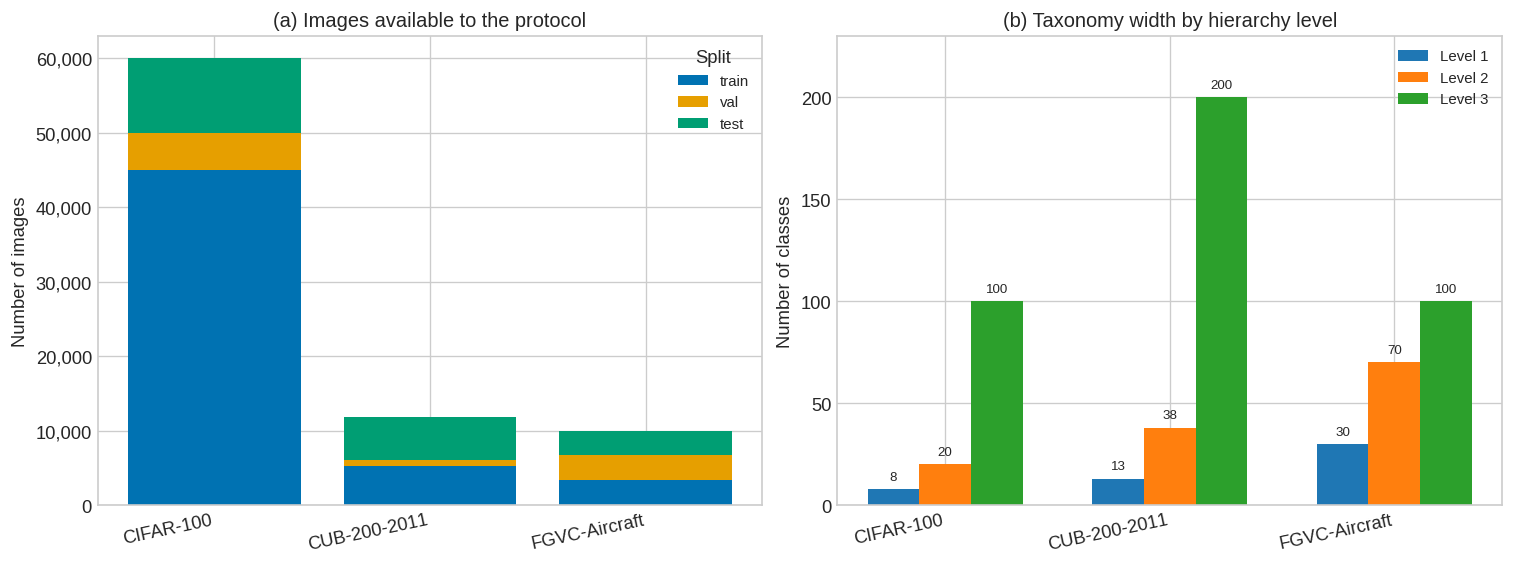

In [6]:
fig, (ax_samples, ax_classes) = plt.subplots(1, 2, figsize=(12.5, 4.6))
dataset_order = list(DATASET_SPECS)
x = np.arange(len(dataset_order))
bottom = np.zeros(len(dataset_order))
for split in ('train', 'val', 'test'):
    values = [len(datasets_by_name[name]['splits'][split]) for name in dataset_order]
    ax_samples.bar(x, values, bottom=bottom, label=split, color=SPLIT_COLORS[split])
    bottom += values
ax_samples.set_xticks(x, dataset_order, rotation=12, ha='right')
ax_samples.set_ylabel('Number of images')
ax_samples.set_title('(a) Images available to the protocol')
ax_samples.legend(title='Split')
ax_samples.yaxis.set_major_formatter(lambda value, _: f'{int(value):,}')

width = 0.23
for level_idx in range(3):
    values = [datasets_by_name[name]['splits']['train'].num_classes_per_level[level_idx] for name in dataset_order]
    labels = [datasets_by_name[name]['cfg'].dataset.levels[level_idx] for name in dataset_order]
    bars = ax_classes.bar(x + (level_idx - 1) * width, values, width, label=f'Level {level_idx + 1}')
    for bar, value in zip(bars, values):
        ax_classes.text(bar.get_x() + bar.get_width()/2, value + 3, str(value), ha='center', va='bottom', fontsize=8)
ax_classes.set_xticks(x, dataset_order, rotation=12, ha='right')
ax_classes.set_ylabel('Number of classes')
ax_classes.set_title('(b) Taxonomy width by hierarchy level')
ax_classes.legend()
ax_classes.set_ylim(0, 230)

fig.savefig(FIGURE_DIR / 'dataset_scale_and_taxonomy_width.pdf', bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'dataset_scale_and_taxonomy_width.png', bbox_inches='tight')
plt.show()


## Sample balance and split representativeness

A dataset can be structurally unbalanced even when every leaf class has almost the same number of images. The plots below therefore keep **sample imbalance** separate from **hierarchy imbalance**. The Jensen–Shannon divergence measures how closely validation and test reproduce the training leaf-class distribution; zero denotes identical distributions.


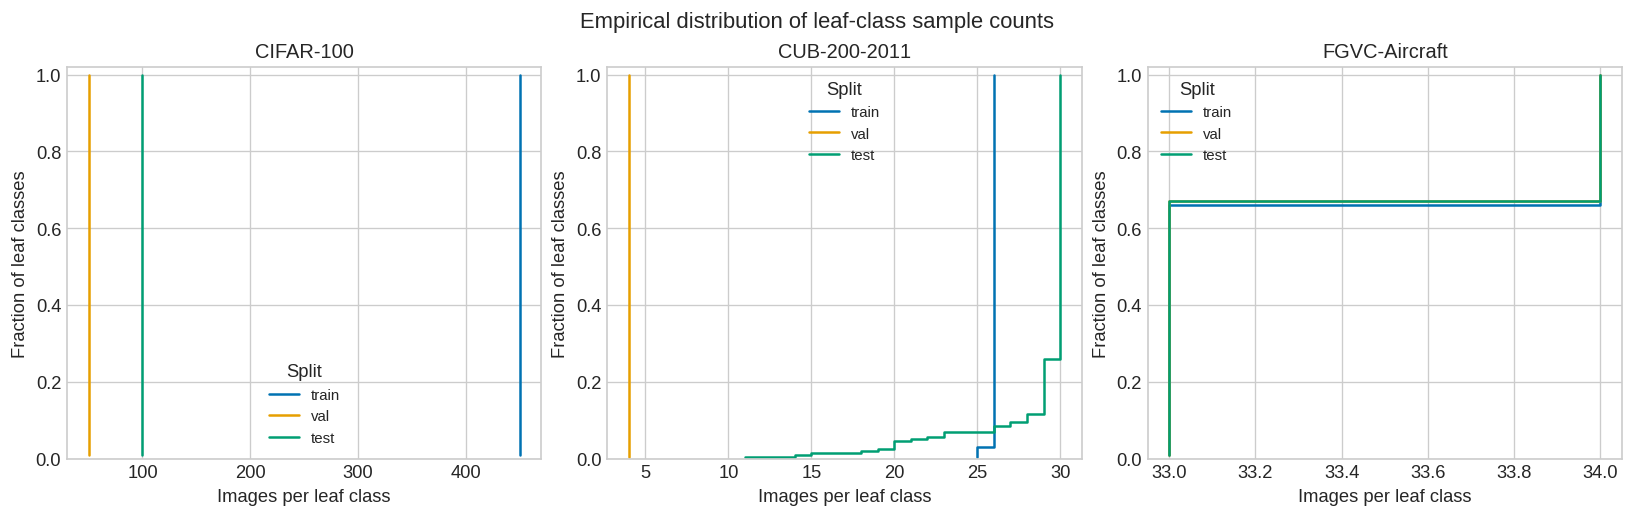

,dataset,split,minimum,median,maximum,gini,coefficient_of_variation
0,CIFAR-100,train,450,450.0,450,0.000,0.000
1,CIFAR-100,val,50,50.0,50,0.000,0.000
2,CIFAR-100,test,100,100.0,100,0.000,0.000
3,CUB-200-2011,train,25,26.0,26,0.001,0.007
4,CUB-200-2011,val,4,4.0,4,0.000,0.000
5,CUB-200-2011,test,11,30.0,30,0.031,0.101
6,FGVC-Aircraft,train,33,33.0,34,0.007,0.014
7,FGVC-Aircraft,val,33,33.0,34,0.007,0.014
8,FGVC-Aircraft,test,33,33.0,34,0.007,0.014


,Dataset,Compared with train,Jensen-Shannon divergence (bits)
0,CIFAR-100,val,0.00000
1,CIFAR-100,test,0.00000
2,CUB-200-2011,val,0.00001
3,CUB-200-2011,test,0.00233
4,FGVC-Aircraft,val,0.00011
5,FGVC-Aircraft,test,0.00011


In [7]:
def leaf_count_vector(dataset_name, split):
    bundle = datasets_by_name[dataset_name]
    leaf = str(bundle['cfg'].dataset.levels[-1])
    n_leaf = bundle['splits']['train'].num_classes_per_level[-1]
    frame = samples.query('dataset == @dataset_name and split == @split')
    return frame[leaf].value_counts().reindex(range(n_leaf), fill_value=0).sort_index().to_numpy()

def js_divergence(counts_a, counts_b):
    p = np.asarray(counts_a, dtype=float)
    q = np.asarray(counts_b, dtype=float)
    p, q = p / p.sum(), q / q.sum()
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * np.log2(a[mask] / b[mask]))
    return float(0.5 * kl(p, m) + 0.5 * kl(q, m))

balance_rows = []
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=False)
for ax, dataset_name in zip(axes, DATASET_SPECS):
    for split in ('train', 'val', 'test'):
        counts = np.sort(leaf_count_vector(dataset_name, split))
        y = np.arange(1, len(counts) + 1) / len(counts)
        ax.step(counts, y, where='post', label=split, color=SPLIT_COLORS[split])
        balance_rows.append({
            'dataset': dataset_name, 'split': split, 'minimum': int(counts.min()),
            'median': float(np.median(counts)), 'maximum': int(counts.max()),
            'gini': gini(counts),
            'coefficient_of_variation': float(np.std(counts) / np.mean(counts)),
        })
    ax.set_title(dataset_name)
    ax.set_xlabel('Images per leaf class')
    ax.set_ylabel('Fraction of leaf classes')
    ax.legend(title='Split')
    ax.set_ylim(0, 1.02)
fig.suptitle('Empirical distribution of leaf-class sample counts')
fig.savefig(FIGURE_DIR / 'leaf_class_balance.pdf', bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'leaf_class_balance.png', bbox_inches='tight')
plt.show()

balance_summary = pd.DataFrame(balance_rows)
balance_summary.to_csv(TABLE_DIR / 'leaf_class_balance.csv', index=False)
display(balance_summary.style.format({'median': '{:.1f}', 'gini': '{:.3f}', 'coefficient_of_variation': '{:.3f}'}))

js_rows = []
for dataset_name in DATASET_SPECS:
    train_counts = leaf_count_vector(dataset_name, 'train')
    for split in ('val', 'test'):
        js_rows.append({
            'Dataset': dataset_name, 'Compared with train': split,
            'Jensen-Shannon divergence (bits)': js_divergence(train_counts, leaf_count_vector(dataset_name, split)),
        })
split_representativeness = pd.DataFrame(js_rows)
split_representativeness.to_csv(TABLE_DIR / 'split_representativeness.csv', index=False)
display(split_representativeness.style.format({'Jensen-Shannon divergence (bits)': '{:.5f}'}))


## Hierarchy structure and imbalance

Two complementary quantities describe each taxonomy. **Branching factor** counts the immediate children of every parent at a transition. **Leaf descendants per root** counts how many fine classes ultimately belong to each top-level class. Large ranges or high coefficients of variation indicate that top-level errors do not all exclude the same number of fine classes, which matters when interpreting hierarchy-aware distances and path accuracy.


In [8]:
def taxonomy_frames(dataset_name, bundle):
    levels = list(bundle['cfg'].dataset.levels)
    taxonomy = bundle['splits']['train'].taxonomy
    counts = bundle['splits']['train'].num_classes_per_level
    edges = []
    branching = []
    for child_level in range(1, len(levels)):
        parent_map = taxonomy['parent_of'][child_level]
        child_counts = Counter(int(parent) for parent in parent_map.values())
        for child, parent in sorted(parent_map.items()):
            edges.append({
                'dataset': dataset_name, 'transition': f'{levels[child_level-1]} → {levels[child_level]}',
                'parent_level': levels[child_level-1], 'child_level': levels[child_level],
                'parent_id': int(parent), 'child_id': int(child),
            })
        for parent in range(counts[child_level - 1]):
            branching.append({
                'dataset': dataset_name, 'transition': f'{levels[child_level-1]} → {levels[child_level]}',
                'parent_id': parent, 'children': child_counts.get(parent, 0),
            })
    return pd.DataFrame(edges), pd.DataFrame(branching)

edge_frames, branching_frames = [], []
for name, bundle in datasets_by_name.items():
    edge_frame, branch_frame = taxonomy_frames(name, bundle)
    edge_frames.append(edge_frame)
    branching_frames.append(branch_frame)
taxonomy_edges = pd.concat(edge_frames, ignore_index=True)
branching = pd.concat(branching_frames, ignore_index=True)
taxonomy_edges.to_csv(TABLE_DIR / 'taxonomy_edges.csv', index=False)
branching.to_csv(TABLE_DIR / 'hierarchy_branching_factors.csv', index=False)

hierarchy_summary = (branching.groupby(['dataset', 'transition'])['children']
    .agg(parents='count', children='sum', minimum='min', median='median', mean='mean', maximum='max', std='std')
    .reset_index())
hierarchy_summary['coefficient_of_variation'] = hierarchy_summary['std'] / hierarchy_summary['mean']
hierarchy_summary['single_child_parents'] = [
    int((branching.query('dataset == @d and transition == @t').children == 1).sum())
    for d, t in hierarchy_summary[['dataset', 'transition']].itertuples(index=False, name=None)
]
hierarchy_summary.to_csv(TABLE_DIR / 'hierarchy_summary.csv', index=False)
display(hierarchy_summary.style.format({'median': '{:.1f}', 'mean': '{:.2f}', 'std': '{:.2f}', 'coefficient_of_variation': '{:.3f}'}))


,dataset,transition,parents,children,minimum,median,mean,maximum,std,coefficient_of_variation,single_child_parents
0,CIFAR-100,coarse1 → coarse2,8,20,1,2.0,2.50,5,1.20,0.478,1
1,CIFAR-100,coarse2 → fine,20,100,5,5.0,5.00,5,0.00,0.000,0
2,CUB-200-2011,family → species,38,200,1,3.5,5.26,30,6.20,1.178,12
3,CUB-200-2011,order → family,13,38,1,1.0,2.92,21,5.47,1.871,8
4,FGVC-Aircraft,family → variant,70,100,1,1.0,1.43,8,1.08,0.759,54
5,FGVC-Aircraft,manufacturer → family,30,70,1,2.0,2.33,8,1.81,0.774,14


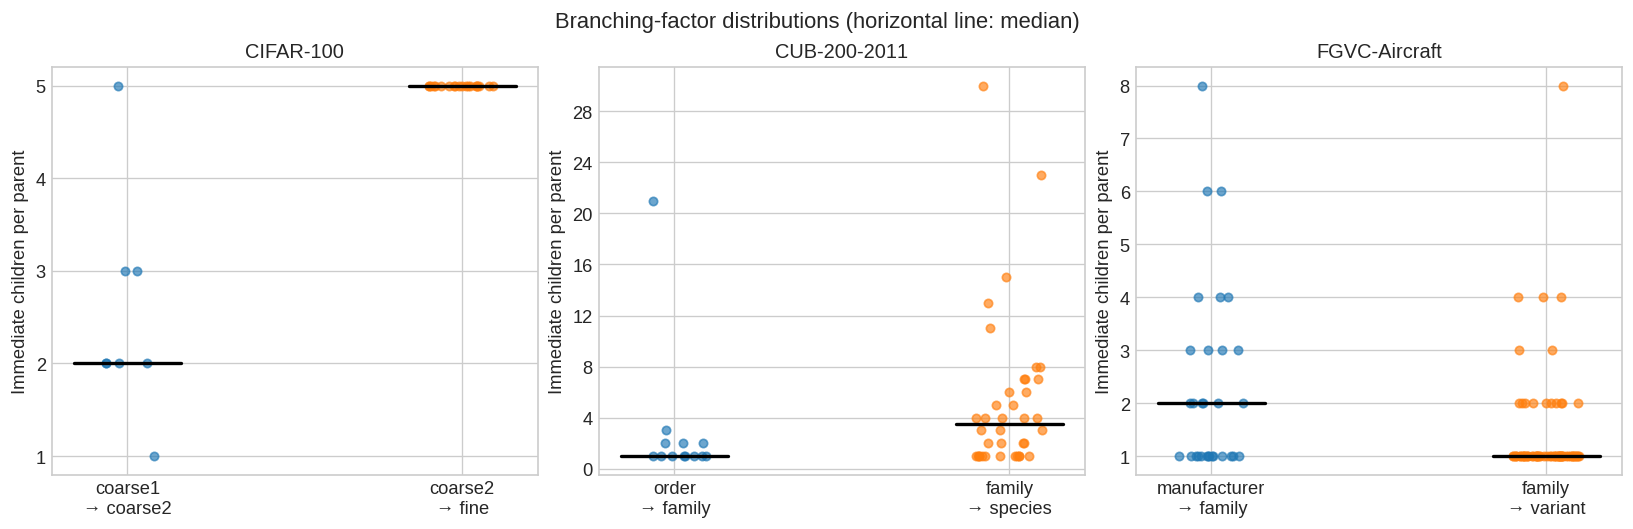

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3), sharey=False)
for ax, dataset_name in zip(axes, DATASET_SPECS):
    subset = branching.query('dataset == @dataset_name')
    transitions = list(subset.transition.unique())
    for transition_idx, transition in enumerate(transitions):
        values = subset.query('transition == @transition').children.to_numpy()
        rng = np.random.default_rng(RANDOM_SEED + transition_idx)
        jitter = rng.uniform(-0.10, 0.10, size=len(values))
        ax.scatter(np.full(len(values), transition_idx) + jitter, values, alpha=0.65, s=25, label=transition)
        ax.plot([transition_idx - 0.16, transition_idx + 0.16], [np.median(values)] * 2, color='black', linewidth=2)
    ax.set_xticks(range(len(transitions)), [t.replace(' → ', '\n→ ') for t in transitions])
    ax.set_ylabel('Immediate children per parent')
    ax.set_title(dataset_name)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
fig.suptitle('Branching-factor distributions (horizontal line: median)')
fig.savefig(FIGURE_DIR / 'hierarchy_branching_factors.pdf', bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'hierarchy_branching_factors.png', bbox_inches='tight')
plt.show()


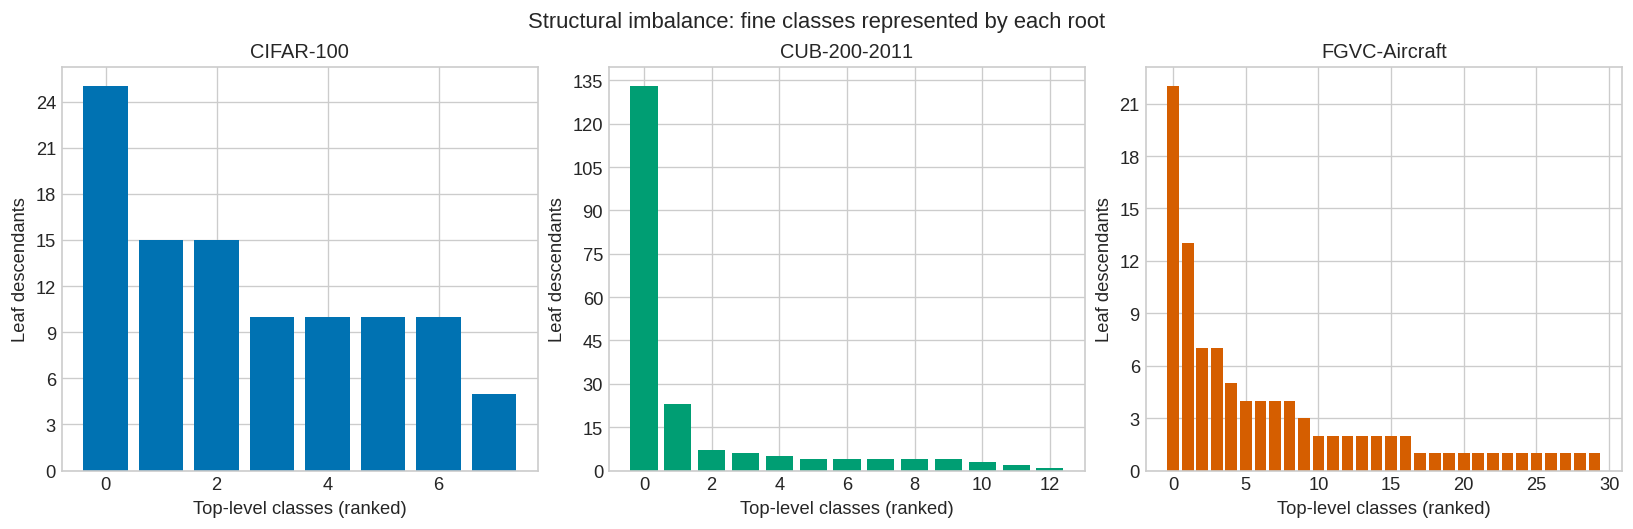

In [10]:
descendant_rows = []
for dataset_name, bundle in datasets_by_name.items():
    taxonomy = bundle['splits']['train'].taxonomy['parent_of']
    n_root = bundle['splits']['train'].num_classes_per_level[0]
    middle_to_root = {int(child): int(parent) for child, parent in taxonomy[1].items()}
    leaf_to_middle = {int(child): int(parent) for child, parent in taxonomy[2].items()}
    counts = Counter(middle_to_root[middle] for middle in leaf_to_middle.values())
    for root_id in range(n_root):
        descendant_rows.append({'dataset': dataset_name, 'root_id': root_id, 'leaf_descendants': counts[root_id]})
leaf_descendants = pd.DataFrame(descendant_rows)
leaf_descendants.to_csv(TABLE_DIR / 'leaf_descendants_per_root.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3), sharey=False)
for ax, dataset_name in zip(axes, DATASET_SPECS):
    values = leaf_descendants.query('dataset == @dataset_name').sort_values('leaf_descendants', ascending=False)
    ax.bar(np.arange(len(values)), values.leaf_descendants, color=COLORS[dataset_name])
    ax.set_xlabel('Top-level classes (ranked)')
    ax.set_ylabel('Leaf descendants')
    ax.set_title(dataset_name)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
fig.suptitle('Structural imbalance: fine classes represented by each root')
fig.savefig(FIGURE_DIR / 'leaf_descendants_per_root.pdf', bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'leaf_descendants_per_root.png', bbox_inches='tight')
plt.show()


## Image geometry

Resolution and aspect ratio characterize the visual input before model-specific resizing or cropping. CIFAR-100 is a fixed 32×32 low-resolution benchmark; CUB and Aircraft contain higher-resolution photographs with variable geometry. The scan is deterministic and reports its sample size, so the resulting estimates are auditable.


In [11]:
def deterministic_indices(length, maximum, seed):
    if length <= maximum:
        return np.arange(length)
    return np.sort(np.random.default_rng(seed).choice(length, size=maximum, replace=False))

geometry_rows = []
for dataset_idx, (dataset_name, bundle) in enumerate(datasets_by_name.items()):
    for split_idx, (split, dataset) in enumerate(bundle['splits'].items()):
        indices = deterministic_indices(len(dataset), MAX_IMAGES_PER_SPLIT, RANDOM_SEED + 10 * dataset_idx + split_idx)
        for index in indices:
            image = dataset._load_image(dataset.samples[int(index)]['image'])
            width, height = image.size
            geometry_rows.append({
                'dataset': dataset_name, 'split': split, 'width': width, 'height': height,
                'megapixels': width * height / 1_000_000, 'aspect_ratio': width / height,
            })
            image.close()
image_geometry = pd.DataFrame(geometry_rows)
image_geometry.to_csv(TABLE_DIR / 'sampled_image_geometry.csv', index=False)

geometry_summary = (image_geometry.groupby(['dataset', 'split'])
    .agg(images_scanned=('width', 'size'), width_median=('width', 'median'), height_median=('height', 'median'),
         megapixels_median=('megapixels', 'median'), megapixels_min=('megapixels', 'min'),
         megapixels_max=('megapixels', 'max'), aspect_ratio_median=('aspect_ratio', 'median'))
    .reset_index())
geometry_summary.to_csv(TABLE_DIR / 'image_geometry_summary.csv', index=False)
display(geometry_summary.style.format({
    'width_median': '{:.0f}', 'height_median': '{:.0f}', 'megapixels_median': '{:.3f}',
    'megapixels_min': '{:.3f}', 'megapixels_max': '{:.3f}', 'aspect_ratio_median': '{:.2f}',
}))


,dataset,split,images_scanned,width_median,height_median,megapixels_median,megapixels_min,megapixels_max,aspect_ratio_median
0,CIFAR-100,test,2000,32,32,0.001,0.001,0.001,1.00
1,CIFAR-100,train,2000,32,32,0.001,0.001,0.001,1.00
2,CIFAR-100,val,2000,32,32,0.001,0.001,0.001,1.00
3,CUB-200-2011,test,2000,500,374,0.178,0.022,0.250,1.33
4,CUB-200-2011,train,2000,500,375,0.178,0.019,0.250,1.33
5,CUB-200-2011,val,800,500,372,0.178,0.020,0.250,1.33
6,FGVC-Aircraft,test,2000,1024,697,0.714,0.330,1.915,1.47
7,FGVC-Aircraft,train,2000,1024,699,0.716,0.350,1.901,1.47
8,FGVC-Aircraft,val,2000,1024,697,0.715,0.333,1.928,1.47


/tmp/ipykernel_1091483/197190091.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_aspect.boxplot(aspect_data, labels=list(DATASET_SPECS), showfliers=False, patch_artist=True,


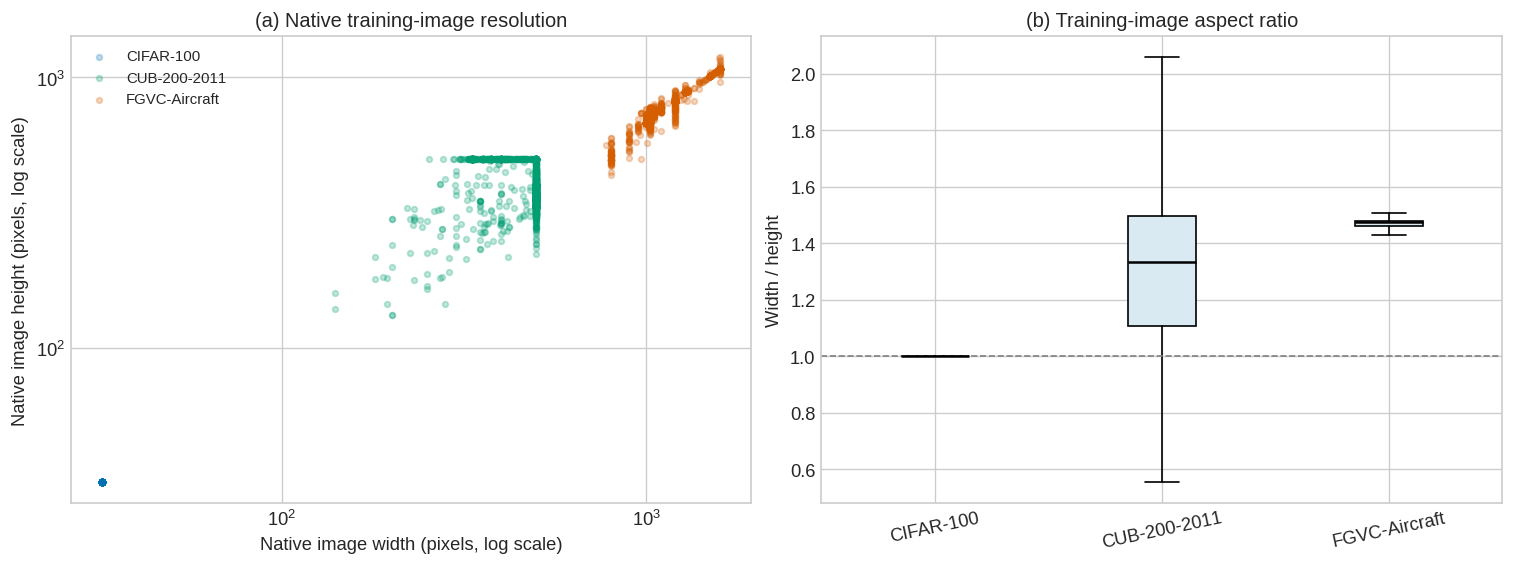

In [12]:
fig, (ax_pixels, ax_aspect) = plt.subplots(1, 2, figsize=(12.5, 4.6))
for dataset_name in DATASET_SPECS:
    values = image_geometry.query("dataset == @dataset_name and split == 'train'")
    ax_pixels.scatter(values.width, values.height, s=12, alpha=0.25, label=dataset_name, color=COLORS[dataset_name])
ax_pixels.set_xscale('log')
ax_pixels.set_yscale('log')
ax_pixels.set_xlabel('Native image width (pixels, log scale)')
ax_pixels.set_ylabel('Native image height (pixels, log scale)')
ax_pixels.set_title('(a) Native training-image resolution')
ax_pixels.legend()

aspect_data = [image_geometry.query("dataset == @name and split == 'train'").aspect_ratio for name in DATASET_SPECS]
ax_aspect.boxplot(aspect_data, labels=list(DATASET_SPECS), showfliers=False, patch_artist=True,
                  boxprops={'facecolor': '#D9EAF2'}, medianprops={'color': 'black', 'linewidth': 1.5})
ax_aspect.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax_aspect.set_ylabel('Width / height')
ax_aspect.set_title('(b) Training-image aspect ratio')
ax_aspect.tick_params(axis='x', rotation=12)
fig.savefig(FIGURE_DIR / 'native_image_geometry.pdf', bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'native_image_geometry.png', bbox_inches='tight')
plt.show()


## Representative images

The gallery samples distinct leaf classes from the training split using a fixed seed. It is intended to illustrate the difference between object-centric 32×32 images, fine-grained bird recognition, and fine-grained aircraft recognition—not to establish quantitative difficulty.


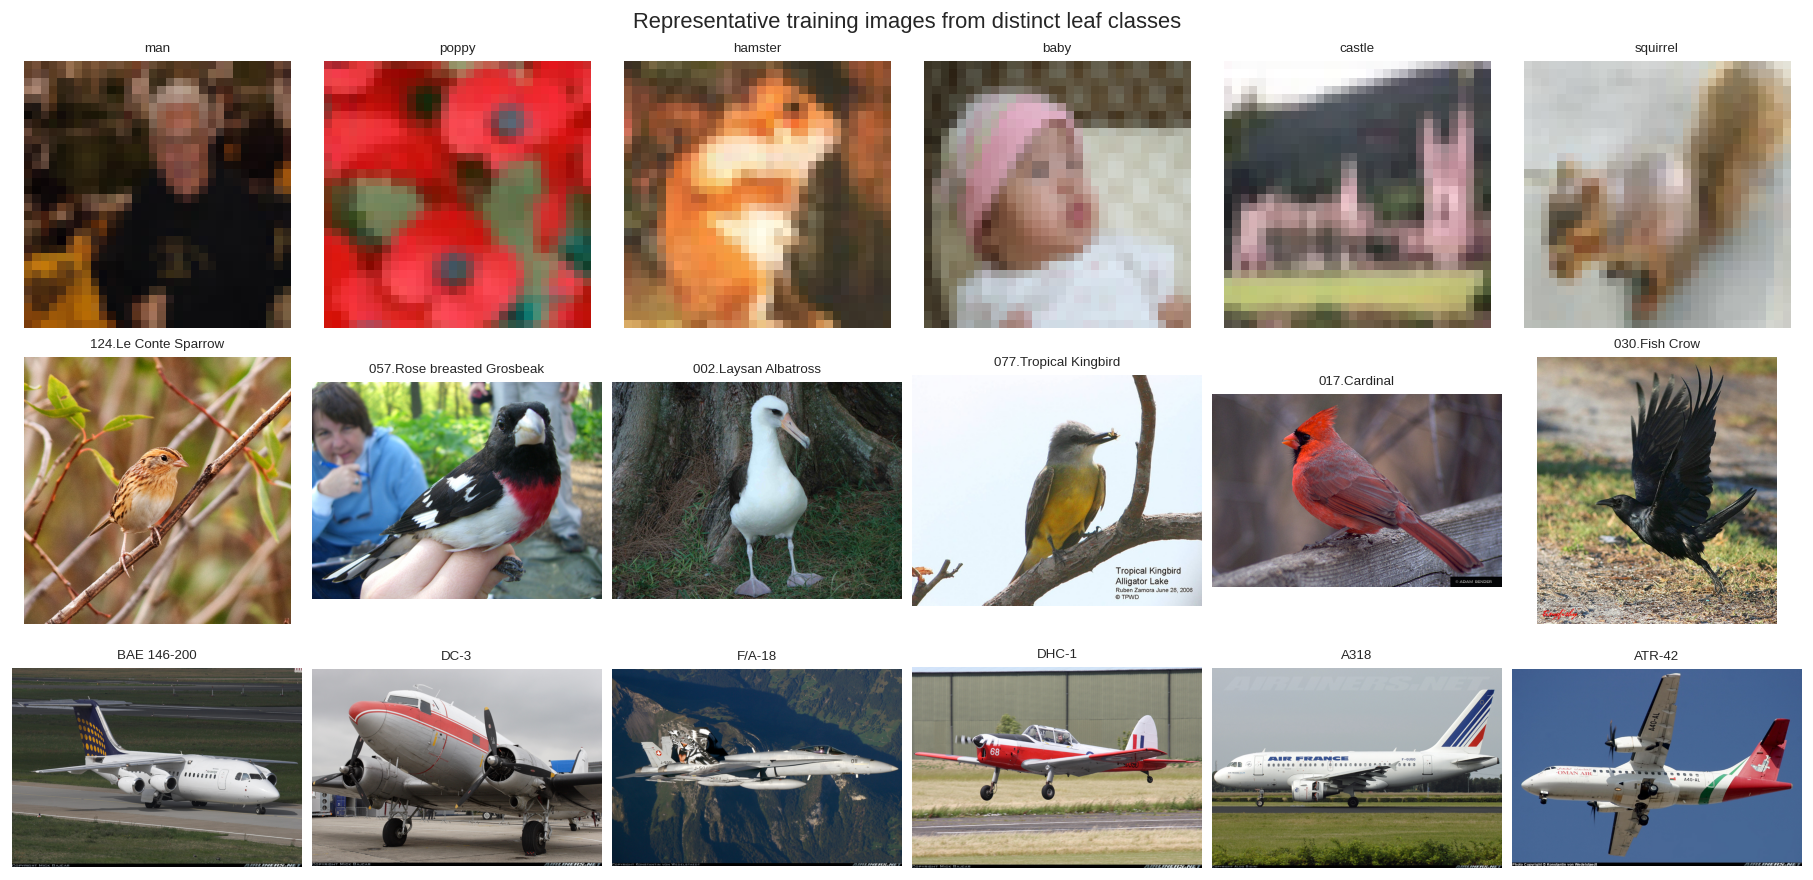

In [13]:
def leaf_name(dataset_name, dataset, sample):
    leaf_id = int(sample['labels'][-1])
    if dataset_name == 'CIFAR-100':
        meta_path = Path(dataset.root) / 'cifar-100-python' / 'meta'
        if not meta_path.exists():
            meta_path = Path(dataset.root) / 'meta'
        if meta_path.exists():
            with meta_path.open('rb') as handle:
                payload = pickle.load(handle, encoding='latin1')
            names = payload.get('fine_label_names', payload.get(b'fine_label_names'))
            if names:
                value = names[leaf_id]
                return value.decode() if isinstance(value, bytes) else str(value)
    if dataset_name == 'CUB-200-2011':
        candidates = [Path(dataset.root) / 'classes.txt', Path(dataset.root) / 'CUB_200_2011' / 'classes.txt']
        path = next((p for p in candidates if p.exists()), None)
        if path:
            rows = [line.strip().split(maxsplit=1)[1] for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
            return rows[leaf_id].replace('_', ' ')
    if dataset_name == 'FGVC-Aircraft':
        return str(sample['meta'].get('variant_name', f'variant {leaf_id}'))
    return f'leaf {leaf_id}'

N_EXAMPLES = 6
fig, axes = plt.subplots(3, N_EXAMPLES, figsize=(15, 7.5))
for row, (dataset_name, bundle) in enumerate(datasets_by_name.items()):
    dataset = bundle['splits']['train']
    by_leaf = {}
    for index, sample in enumerate(dataset.samples):
        by_leaf.setdefault(int(sample['labels'][-1]), index)
    leaves = np.array(sorted(by_leaf))
    chosen = np.random.default_rng(RANDOM_SEED + row).choice(leaves, size=N_EXAMPLES, replace=False)
    for col, leaf in enumerate(chosen):
        sample = dataset.samples[by_leaf[int(leaf)]]
        image = dataset._load_image(sample['image'])
        axes[row, col].imshow(image)
        axes[row, col].set_title(leaf_name(dataset_name, dataset, sample), fontsize=8)
        axes[row, col].axis('off')
        image.close()
    axes[row, 0].set_ylabel(dataset_name, fontsize=11)
fig.suptitle('Representative training images from distinct leaf classes')
fig.savefig(FIGURE_DIR / 'representative_dataset_images.pdf', bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'representative_dataset_images.png', bbox_inches='tight')
plt.show()


## Automatically generated thesis-ready observations

The statements below are generated from the current data and configuration rather than hard-coded. They are suitable starting points for the datasets subsection, but causal claims about model performance require the experiment results and should not be inferred from descriptive statistics alone.


In [14]:
insights = []
for dataset_name, bundle in datasets_by_name.items():
    levels = list(bundle['cfg'].dataset.levels)
    counts = bundle['splits']['train'].num_classes_per_level
    split_sizes = {split: len(ds) for split, ds in bundle['splits'].items()}
    train_balance = balance_summary.query("dataset == @dataset_name and split == 'train'").iloc[0]
    roots = leaf_descendants.query('dataset == @dataset_name').leaf_descendants
    geom = geometry_summary.query("dataset == @dataset_name and split == 'train'").iloc[0]
    insights.append(
        f"**{dataset_name}.** The protocol uses {split_sizes['train']:,} training, {split_sizes['val']:,} validation, "
        f"and {split_sizes['test']:,} test images with a {counts[0]}→{counts[1]}→{counts[2]} "
        f"{levels[0]}→{levels[1]}→{levels[2]} hierarchy. Training leaf classes contain "
        f"{int(train_balance['minimum'])}–{int(train_balance['maximum'])} images (Gini {train_balance['gini']:.3f}). "
        f"A top-level class covers between {int(roots.min())} and {int(roots.max())} leaf classes. "
        f"The sampled native training images have median geometry {geom['width_median']:.0f}×{geom['height_median']:.0f} pixels "
        f"and median aspect ratio {geom['aspect_ratio_median']:.2f}."
    )

provenance_lines = [f"- **{name}:** {spec['provenance']}." for name, spec in DATASET_SPECS.items()]
display(Markdown('\n\n'.join(insights) + '\n\n**Taxonomy provenance**\n\n' + '\n'.join(provenance_lines)))


**CIFAR-100.** The protocol uses 45,000 training, 5,000 validation, and 10,000 test images with a 8→20→100 coarse1→coarse2→fine hierarchy. Training leaf classes contain 450–450 images (Gini 0.000). A top-level class covers between 5 and 25 leaf classes. The sampled native training images have median geometry 32×32 pixels and median aspect ratio 1.00.

**CUB-200-2011.** The protocol uses 5,194 training, 800 validation, and 5,794 test images with a 13→38→200 order→family→species hierarchy. Training leaf classes contain 25–26 images (Gini 0.001). A top-level class covers between 1 and 133 leaf classes. The sampled native training images have median geometry 500×375 pixels and median aspect ratio 1.33.

**FGVC-Aircraft.** The protocol uses 3,334 training, 3,333 validation, and 3,333 test images with a 30→70→100 manufacturer→family→variant hierarchy. Training leaf classes contain 33–34 images (Gini 0.007). A top-level class covers between 1 and 22 leaf classes. The sampled native training images have median geometry 1024×699 pixels and median aspect ratio 1.47.

**Taxonomy provenance**

- **CIFAR-100:** official fine/coarse labels + published B-CNN upper edge.
- **CUB-200-2011:** official images/split + order/family mapping retained from H-CAST.
- **FGVC-Aircraft:** official parallel manufacturer/family/variant annotations.

## Interpretation guide and limitations

- The three datasets share a depth of three for experimental comparability, but their semantic levels and construction procedures differ. A level index should not be interpreted as equal semantic difficulty across datasets.
- Near-uniform leaf sample counts do not imply a balanced taxonomy. Unequal branching changes the number of descendants represented by a coarse decision and can influence hierarchy-aware metrics.
- The validation splits for CIFAR-100 and CUB are deterministic, leaf-stratified subsets of their original training pools. Aircraft uses the official train, validation, and test partitions.
- Native image geometry describes the source data, not the tensors seen by every model. Model presets use different resize/crop pipelines and, in some cases, different input resolutions.
- Representative images are qualitative examples. They do not measure visual diversity, inter-class similarity, background bias, or intrinsic classification difficulty.
- The CUB order/family mapping is inherited from H-CAST, while the CIFAR upper edge is externally imposed. Results therefore apply to the explicit taxonomies used here and should not be generalized to every possible hierarchy for the same images.


In [15]:
exported = sorted([*FIGURE_DIR.glob('*'), *TABLE_DIR.glob('*')])
print(f'Exported {len(exported)} artifacts to {OUTPUT_DIR}:')
for path in exported:
    print(f'  - {path.relative_to(OUTPUT_DIR)}')


Exported 21 artifacts to /scratch/g.saggini1/outputs/analysis/datasets:
  - figures/dataset_scale_and_taxonomy_width.pdf
  - figures/dataset_scale_and_taxonomy_width.png
  - figures/hierarchy_branching_factors.pdf
  - figures/hierarchy_branching_factors.png
  - figures/leaf_class_balance.pdf
  - figures/leaf_class_balance.png
  - figures/leaf_descendants_per_root.pdf
  - figures/leaf_descendants_per_root.png
  - figures/native_image_geometry.pdf
  - figures/native_image_geometry.png
  - figures/representative_dataset_images.pdf
  - figures/representative_dataset_images.png
  - tables/dataset_split_summary.csv
  - tables/hierarchy_branching_factors.csv
  - tables/hierarchy_summary.csv
  - tables/image_geometry_summary.csv
  - tables/leaf_class_balance.csv
  - tables/leaf_descendants_per_root.csv
  - tables/sampled_image_geometry.csv
  - tables/split_representativeness.csv
  - tables/taxonomy_edges.csv
